In [12]:
import os 
import pandas as pd

import sys
sys.path.append('../src/utils/')

from utils import read_df

In [2]:
TASK = "arxiv"
#TASK = "novelpy"

In [3]:
if TASK == "arxiv":
    TARGET_DATA = "../data/arxiv/arxiv_dataset_all_info.csv"
    TARGET_COLUMN = "novelty"
    ID_COLUMN = "id"
    PREFIX = "arxiv_dataset"
elif TASK == "novelpy":
    TARGET_DATA = None
    TARGET_COLUMN = "score"
    ID_COLUMN = "PMID"
    PREFIX = "novelpy_data"    
else:
    print("UNKNOWN TASK")

In [4]:
if TARGET_DATA is not None:
    df = pd.read_csv(TARGET_DATA)
    df_target = df[[ID_COLUMN, TARGET_COLUMN]].set_index(ID_COLUMN)
else:
    df_target = None

In [13]:
df_results = []

for filename in os.listdir("../results/"):
    if not filename.startswith(PREFIX):
        continue
    filepath = os.path.join("../results", filename)
    df = read_df(filepath, index_col=0).groupby(ID_COLUMN).mean()
    df.columns = [f"{filename[len(PREFIX)+1:-len("_result.csv")]}_score"]
    df_results.append(df)

In [6]:
if df_target is not None:
    df_result = df_target
    start = 0
else:
    df_result = df_results[0]
    start = 1
for df in df_results[start:]:
    df_result = df_result.join(df, how="left")

In [7]:

df_result 

,novelty,specter2_IF_score,specter2_LOF_score,di_values_10years_score
id,,,,
http://arxiv.org/abs/2507.08000v1,0.404221,0.444343,1.018859,NaN
http://arxiv.org/abs/2507.07995v1,0.448729,0.422195,1.051318,NaN
http://arxiv.org/abs/2507.07996v1,0.356179,0.444755,1.011063,NaN
http://arxiv.org/abs/2507.07986v2,0.290938,0.432089,0.996079,NaN
http://arxiv.org/abs/2507.07981v1,0.352823,0.445457,1.007562,NaN
...,...,...,...,...
http://arxiv.org/abs/physics/0311054v1,0.260993,0.465153,1.003274,NaN
http://arxiv.org/abs/physics/0311043v1,0.287764,0.475408,1.013874,NaN
http://arxiv.org/abs/physics/0311027v2,0.539139,0.452516,1.138956,NaN


array([[<Axes: title={'center': 'novelty'}>,
        <Axes: title={'center': 'specter2_IF_score'}>],
       [<Axes: title={'center': 'specter2_LOF_score'}>,
        <Axes: title={'center': 'di_values_10years_score'}>]],
      dtype=object)

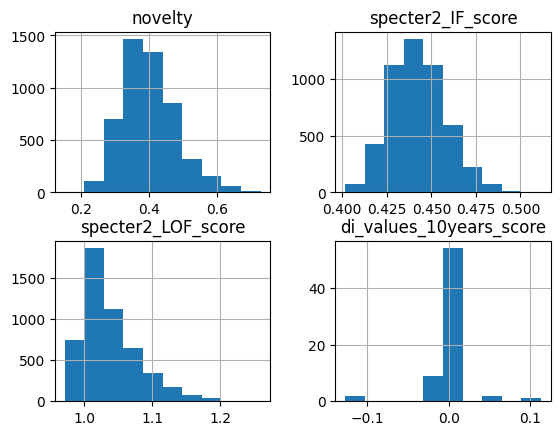

In [8]:
df_result.hist()

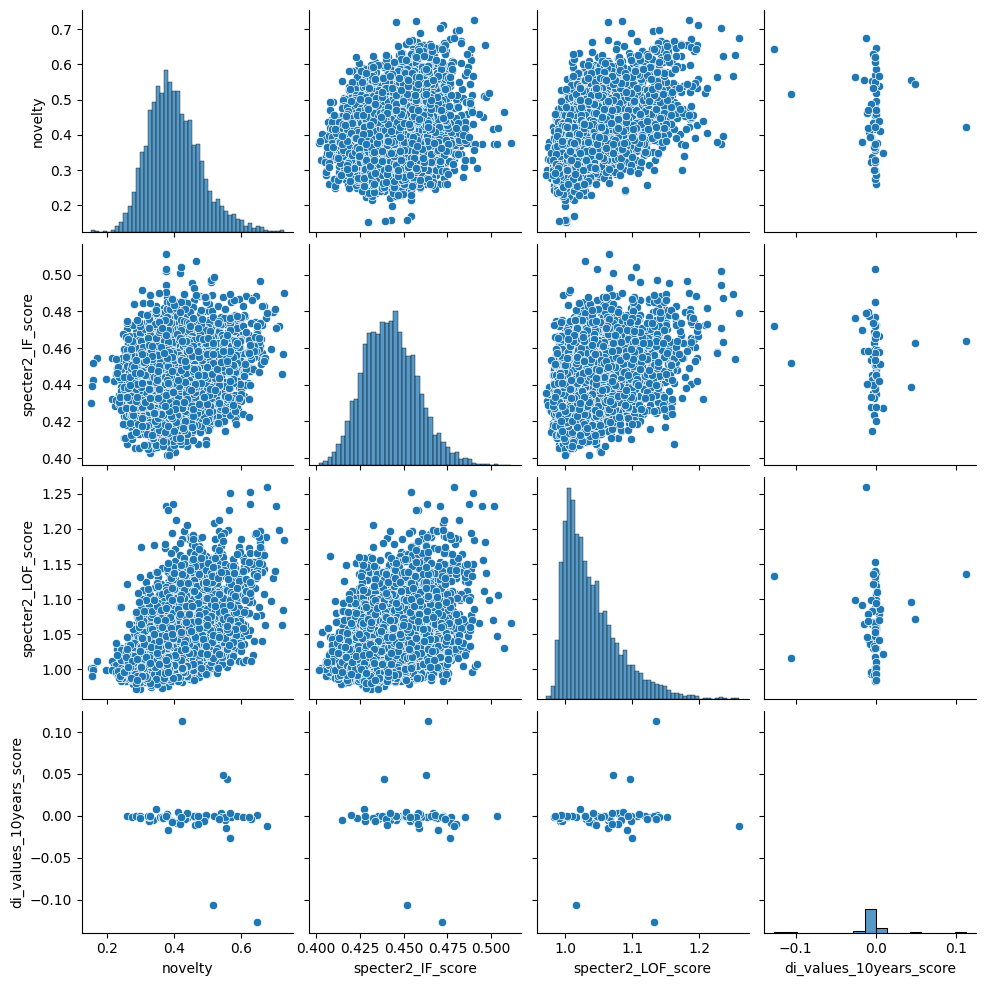

In [9]:
import seaborn as sns
sns.pairplot(df_result)

In [10]:
df_result.corr()

,novelty,specter2_IF_score,specter2_LOF_score,di_values_10years_score
novelty,1.000000,0.239246,0.546462,-0.173558
specter2_IF_score,0.239246,1.000000,0.335716,-0.079493
specter2_LOF_score,0.546462,0.335716,1.000000,0.039165
di_values_10years_score,-0.173558,-0.079493,0.039165,1.000000


In [11]:
df_result.corr(method="spearman")

,novelty,specter2_IF_score,specter2_LOF_score,di_values_10years_score
novelty,1.000000,0.210775,0.542149,-0.086557
specter2_IF_score,0.210775,1.000000,0.295947,-0.147175
specter2_LOF_score,0.542149,0.295947,1.000000,0.010345
di_values_10years_score,-0.086557,-0.147175,0.010345,1.000000
